# AN19 Talker Similarity Analysis (Layer: tr_24)

This notebook implements the advisor's instructions:
1. Pool exposure and test data from AN19.
2. Get all unique combinations of talker, language background, and word.
3. Get all pairwise similarities between recordings of the same word (tau=2, k=1) using features from `tr_24`.
4. Store the pairwise distances/similarities.
5. Group talkers by shared recorded words.
6. Calculate average talker-to-talker similarities and plot as a clustered `inferno` heatmap.


In [ ]:
from project_utils import *


In [1]:
import pandas as pd
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from numba import njit
from scipy.cluster.hierarchy import linkage, leaves_list

# Ignore openpyxl warnings for clean output
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')


In [3]:
h5_path = '../data/features/nygaard19_features.h5'

excel_path = '../data/raw_data/alexander_nygaard19/AN19-exposure-test-behavioral-data.xlsx'
layer_name = 'tr_24' # Using Transformer layer 24 as requested

print("Loading behavioral data...")
df = pd.read_excel(excel_path, engine='openpyxl')

# Fix TrainingAccent NaNs to 'English'
df['TrainingAccent'] = df['TrainingAccent'].fillna('English')

# Extract Speaker (first 3 chars of FileName, lowercase), Accent, Word
df['Talker'] = df['FileName'].astype(str).apply(lambda x: x[:3].lower())


df['L1'] = df['Talker'].apply(infer_accent)

# 1 & 2. Get unique combinations of Talker, L1, Word from df
unique_recs = df[['Talker', 'L1', 'Word']].drop_duplicates()
print(f"Total unique recordings in behavioral data: {len(unique_recs)}")

# 5. Group by matching words.
word_by_talker = unique_recs.groupby('Talker')['Word'].apply(set).to_dict()

# The behavioral dataframe might not have the English Control talkers explicitly listed in 'FileName'.
# We must manually ensure the default English control talkers are added so we can plot L1-English.
english_talkers = ['ef1', 'ef2', 'ef3', 'em1', 'em2', 'em3']
for et in english_talkers:
    if et not in word_by_talker:
        word_by_talker[et] = set() # We will populate their words from the H5 file next

all_talkers = list(word_by_talker.keys())


Loading behavioral data...
Total unique recordings in behavioral data: 1056


In [4]:
print(f"Loading {layer_name} features from H5...")
features = {} # {talker: {word: feature_matrix}}
with h5py.File(h5_path, 'r') as h5f:
    for spk in all_talkers:
        if spk in h5f:
            features[spk] = {}
            for word in h5f[spk]:
                if layer_name in h5f[spk][word]:
                    features[spk][word] = h5f[spk][word][layer_name][:]
                    # Populate word_by_talker for English talkers
                    word_by_talker[spk].add(word)
                    
print(f"Features loaded for {len(features)} talkers.")


Loading tr_24 features from H5...
Features loaded for 42 talkers.


In [5]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import itertools

# 3. Calculate all pairwise similarities
print("Calculating pairwise similarities (tau=2, k=1)...")
pairwise_dists = {}

# Filter talkers to only those we have features for
valid_talkers = [t for t in all_talkers if t in features and len(features[t]) > 0]

def compute_pair_distance(t1, t2, features_t1, features_t2):
    words1 = set(features_t1.keys())
    words2 = set(features_t2.keys())
    shared_words = words1.intersection(words2)
    
    if not shared_words:
        return t1, t2, None
    
    total_dist = 0.0
    count = 0
    for w in shared_words:
        feat1 = features_t1[w]
        feat2 = features_t2[w]
        
        # Using tau=2 for raw distance
        dist = dtw_raw_distance(feat1, feat2, tau=2.0)
        
        # Convert distance to distance using exp(-d*k) where k=1
        total_dist += dist
        count += 1
        
    if count > 0:
        return t1, t2, total_dist / count
    return t1, t2, None

# Generate all pairs
pairs = [(valid_talkers[i], valid_talkers[j]) for i in range(len(valid_talkers)) for j in range(i+1, len(valid_talkers))]
print(f"Total pairs to process: {len(pairs)}")

# Because dtw_raw_distance is a @njit compiled function, it releases the GIL.
# Using prefer='threads' reduces memory overhead and is usually faster for Numba.
results = Parallel(n_jobs=-1, prefer='threads')(
    delayed(compute_pair_distance)(t1, t2, features[t1], features[t2]) 
    for t1, t2 in tqdm(pairs, desc="Pairwise DTW")
)

for t1, t2, avg_dist in results:
    if avg_dist is not None:
        pairwise_dists[(t1, t2)] = avg_dist
        pairwise_dists[(t2, t1)] = avg_dist
        
print(f"\nFinished processing {len(pairs)} pairs.")


Calculating pairwise similarities (tau=2, k=1)...
Total pairs to process: 861


Pairwise DTW:   0%|          | 0/861 [00:00<?, ?it/s]


Finished processing 861 pairs.


In [6]:
# 4 & 6. Matrix Construction & Clustering

english_talkers = [t for t in valid_talkers if infer_accent(t) == 'English']
spanish_talkers = [t for t in valid_talkers if infer_accent(t) == 'Spanish']
korean_talkers = [t for t in valid_talkers if infer_accent(t) == 'Korean']
other_talkers = [t for t in valid_talkers if infer_accent(t) == 'Other']

# Order 'other_talkers' by average distance
if len(other_talkers) > 1:
    n_other = len(other_talkers)
    dist_matrix = np.zeros((n_other, n_other))
    for i, t1 in enumerate(other_talkers):
        for j, t2 in enumerate(other_talkers):
            if i == j:
                dist_matrix[i, j] = 0.0
            else:
                dist = pairwise_dists.get((t1, t2), 0.0)
                dist_matrix[i, j] = dist # Distance for clustering
                
    condensed_dist = []
    for i in range(n_other):
        for j in range(i+1, n_other):
            condensed_dist.append(dist_matrix[i, j])
            
    # Handle case where condensed_dist might have NaNs
    if np.any(np.isnan(condensed_dist)):
        print("Warning: NaN in distance matrix. Filling with 1.0")
        condensed_dist = np.nan_to_num(condensed_dist, nan=1.0)
        
    try:
        Z = linkage(condensed_dist, method='average')
        order = leaves_list(Z)
        other_talkers = [other_talkers[i] for i in order]
    except Exception as e:
        print(f"Clustering failed: {e}. Keeping original order.")
    
ordered_talkers = english_talkers + spanish_talkers + korean_talkers + other_talkers

n_total = len(ordered_talkers)
dist_matrix_plot = np.zeros((n_total, n_total))

for i, t1 in enumerate(ordered_talkers):
    for j, t2 in enumerate(ordered_talkers):
        if i == j:
            dist_matrix_plot[i, j] = np.nan # Use NaN so it doesn't skew the heatmap color scale
        else:
            dist_matrix_plot[i, j] = pairwise_dists.get((t1, t2), 0.0)
            
print(f"Talker Grouping ({n_total} total):")
print(f"  English: {len(english_talkers)}")
print(f"  Spanish: {len(spanish_talkers)}")
print(f"  Korean:  {len(korean_talkers)}")
print(f"  Other:   {len(other_talkers)}")


Talker Grouping (42 total):
  English: 6
  Spanish: 12
  Korean:  12
  Other:   12


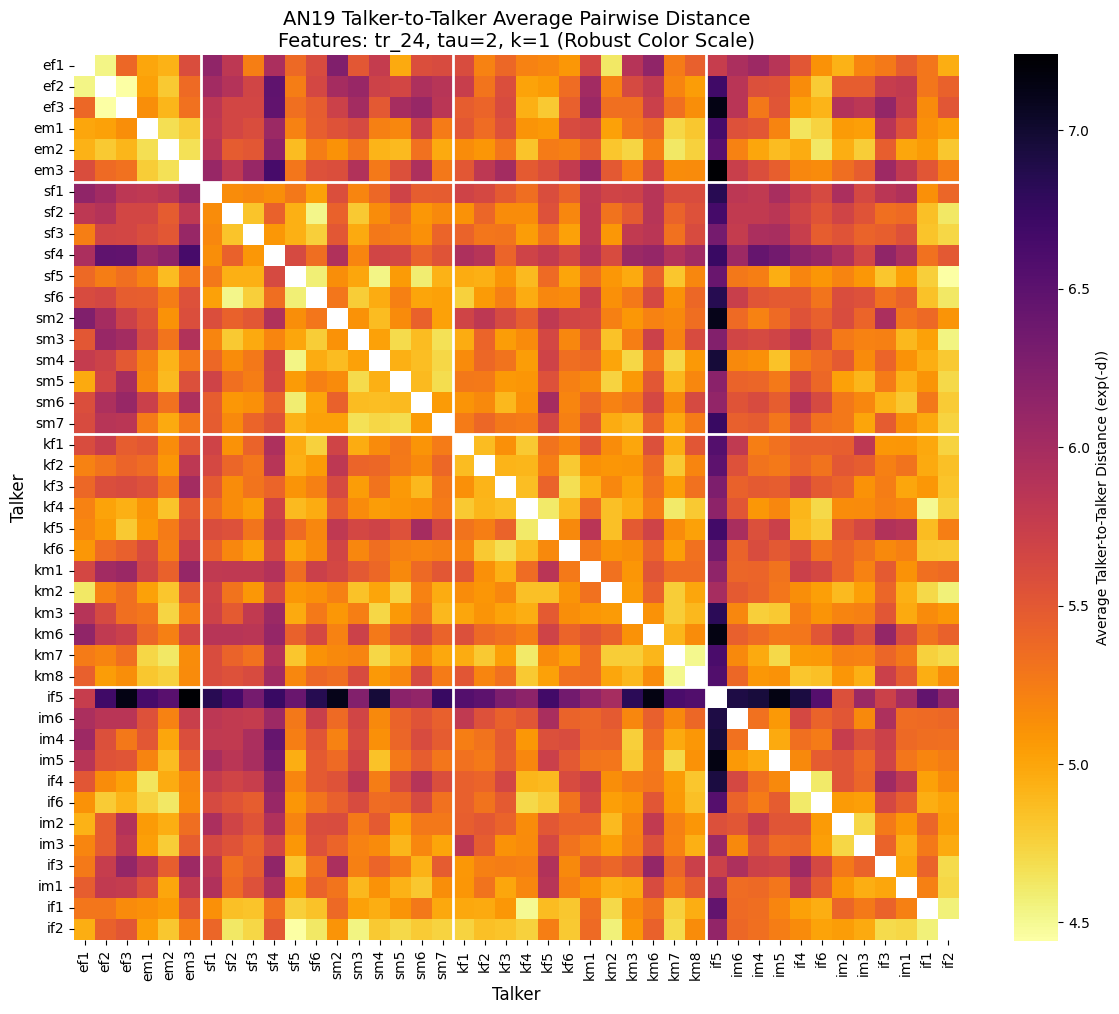

In [15]:
# 5. Visualization
plt.figure(figsize=(12, 10))
# robust=True computes the color map range using robust quantiles instead of extreme values
ax = sns.heatmap(dist_matrix_plot, xticklabels=ordered_talkers, yticklabels=ordered_talkers,
                 cmap='inferno_r', square=True, #robust=True,
                 cbar_kws={'label': 'Average Talker-to-Talker Distance (exp(-d))'})

# Add white lines to separate L1 groups
pos = 0
for group in [english_talkers, spanish_talkers, korean_talkers]:
    if len(group) > 0:
        pos += len(group)
        ax.axhline(pos, color='white', linewidth=2)
        ax.axvline(pos, color='white', linewidth=2)
        
plt.title(f'AN19 Talker-to-Talker Average Pairwise Distance\nFeatures: {layer_name}, tau=2, k=1 (Robust Color Scale)', fontsize=14)
plt.xlabel('Talker', fontsize=12)
plt.ylabel('Talker', fontsize=12)

# Rotate xticklabels
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Save matrix to CSV if needed
df_dist = pd.DataFrame(dist_matrix_plot, index=ordered_talkers, columns=ordered_talkers)
#df_dist.to_csv('an19_talker_distance_T24.csv')
#print("Distance matrix saved to an19_talker_distance_T24.csv")



## Updated Visualizations & Analysis (per Advisor's Comments)
Here we redo the plots and statistical comparisons:
1. Show only the lower triangle (no diagonal).
2. Treat international talkers as their specific language backgrounds (1 talker per language per gender).
3. Label talkers by their language.
4. Calculate within vs between group similarity means and SE, followed by a Welch's t-test and bootstrap analysis.


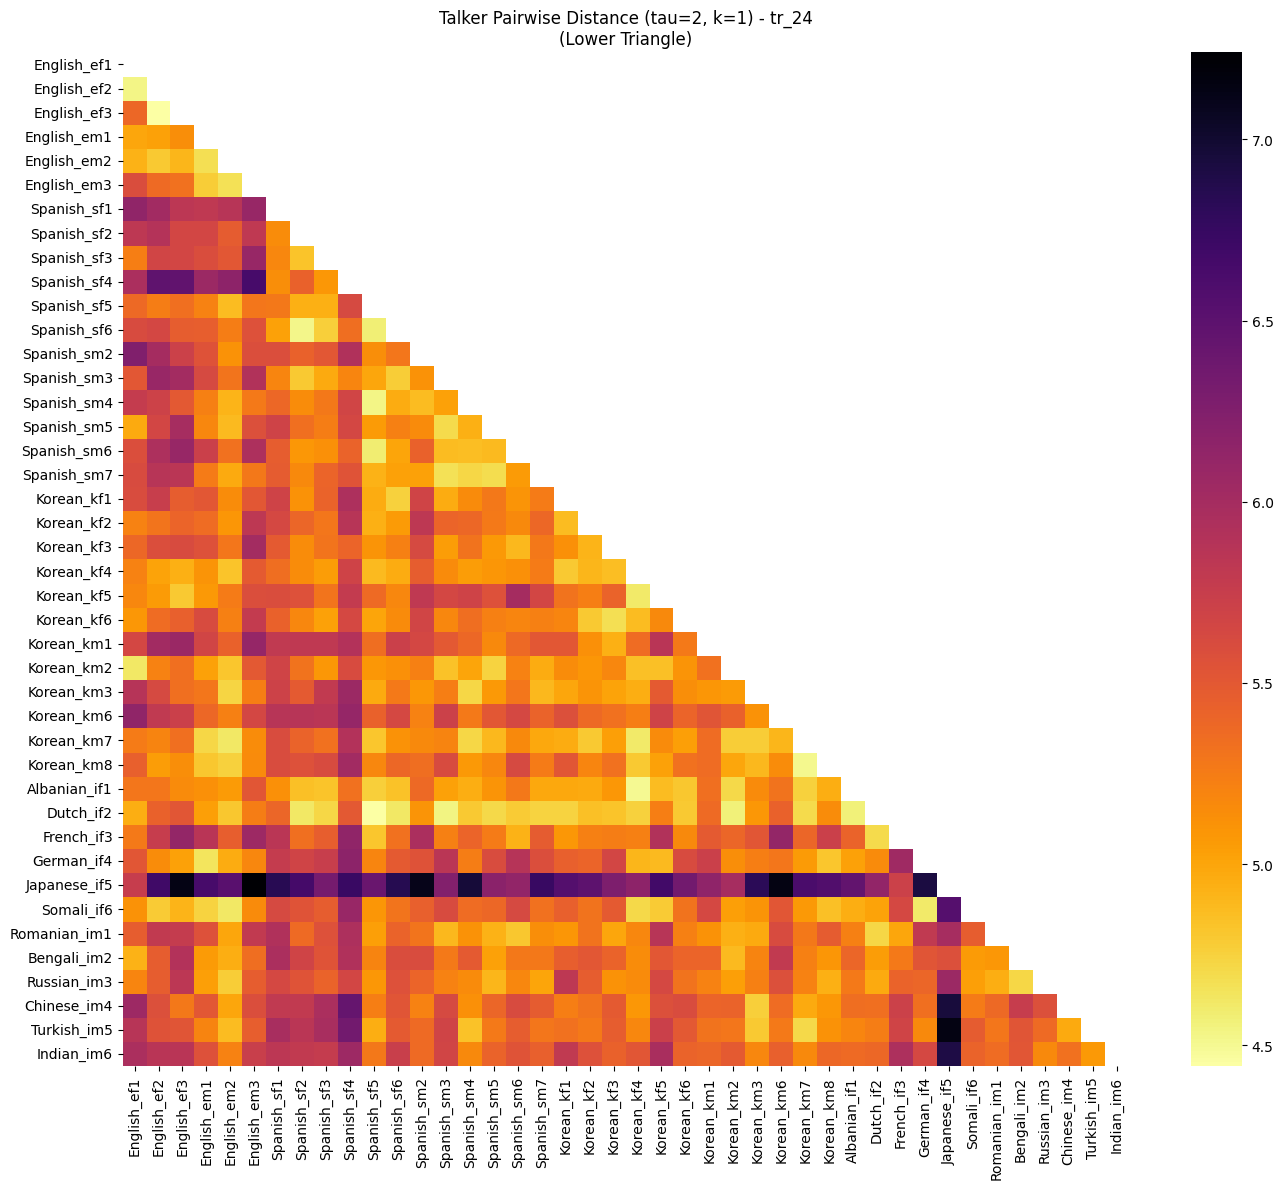

In [17]:

# 1. Language mapping for all talkers
l1_map = {
    'if1': 'Albanian',
    'if2': 'Dutch',
    'if3': 'French',
    'if4': 'German',
    'if5': 'Japanese',
    'if6': 'Somali',
    'im1': 'Romanian',
    'im2': 'Bengali',
    'im3': 'Russian',
    'im4': 'Chinese',
    'im5': 'Turkish',
    'im6': 'Indian'
}

def get_talker_label(t):
    if t.startswith('e'):
        return f"English_{t}"
    elif t.startswith('k'):
        return f"Korean_{t}"
    elif t.startswith('s'):
        return f"Spanish_{t}"
    elif t in l1_map:
        return f"{l1_map[t]}_{t}"
    return t
    
def get_talker_group(t):
    if t.startswith('e'): return 'English'
    if t.startswith('k'): return 'Korean'
    if t.startswith('s'): return 'Spanish'
    return l1_map.get(t, 'Other')

# We can re-sort the talkers so males/females are grouped together cleanly
english_talkers = sorted([t for t in valid_talkers if get_talker_group(t) == 'English'])
spanish_talkers = sorted([t for t in valid_talkers if get_talker_group(t) == 'Spanish'])
korean_talkers = sorted([t for t in valid_talkers if get_talker_group(t) == 'Korean'])
intl_talkers = sorted([t for t in valid_talkers if t.startswith('i')])

# Concatenate all sorted talkers
new_ordered_talkers = english_talkers + spanish_talkers + korean_talkers + intl_talkers
ordered_labels = [get_talker_label(t) for t in new_ordered_talkers]

# Rebuild the distance matrix with the new ordering
n_total = len(new_ordered_talkers)
new_dist_matrix = np.zeros((n_total, n_total))

for i, t1 in enumerate(new_ordered_talkers):
    for j, t2 in enumerate(new_ordered_talkers):
        if i == j:
            new_dist_matrix[i, j] = np.nan # Use NaN so it doesn't skew the heatmap color scale
        else:
            new_dist_matrix[i, j] = pairwise_dists.get((t1, t2), 0.0)

# Create lower triangle mask
mask = np.triu(np.ones_like(new_dist_matrix, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(new_dist_matrix, mask=mask, xticklabels=ordered_labels, yticklabels=ordered_labels, 
            cmap='inferno_r', annot=False, fmt='.4f', vmin=np.nanmin(new_dist_matrix), vmax=np.nanmax(new_dist_matrix))
plt.title(f"Talker Pairwise Distance (tau=2, k=1) - {layer_name}\n(Lower Triangle)")
plt.tight_layout()
plt.show()


In [18]:
# 2. Within vs Between Group Distance Analysis
import scipy.stats as stats
import numpy as np

within_dists = []
between_dists = []

for i in range(len(valid_talkers)):
    for j in range(i+1, len(valid_talkers)):
        t1, t2 = valid_talkers[i], valid_talkers[j]
        g1, g2 = get_talker_group(t1), get_talker_group(t2)
        dist = pairwise_dists.get((t1, t2), np.nan)
        
        if not np.isnan(dist):
            if g1 == g2:
                # Only L1-English, L1-Korean, and L1-Spanish have >1 talker
                within_dists.append(dist)
            else:
                between_dists.append(dist)

mean_within = np.mean(within_dists)
se_within = stats.sem(within_dists)

mean_between = np.mean(between_dists)
se_between = stats.sem(between_dists)

print(f"Mean Within-Group Distance:  {mean_within:.4f} (SE: {se_within:.4f})")
print(f"Mean Between-Group Distance: {mean_between:.4f} (SE: {se_between:.4f})")

# Welch's t-test
t_stat, p_val = stats.ttest_ind(within_dists, between_dists, equal_var=False)
print(f"Welch's t-test: t = {t_stat:.4f}, p = {p_val:.4e}")

# Bootstrap testing
n_boot = 10000
diffs = []
for _ in range(n_boot):
    boot_within = np.random.choice(within_dists, size=len(within_dists), replace=True)
    boot_between = np.random.choice(between_dists, size=len(between_dists), replace=True)
    diffs.append(np.mean(boot_within) - np.mean(boot_between))

p_boot = np.mean(np.array(diffs) >= 0)
print(f"Bootstrap p-value (Within < Between): {p_boot:.4e}")


Mean Within-Group Distance:  5.1023 (SE: 0.0247)
Mean Between-Group Distance: 5.4307 (SE: 0.0171)
Welch's t-test: t = -10.9534, p = 9.0705e-24
Bootstrap p-value (Within < Between): 0.0000e+00


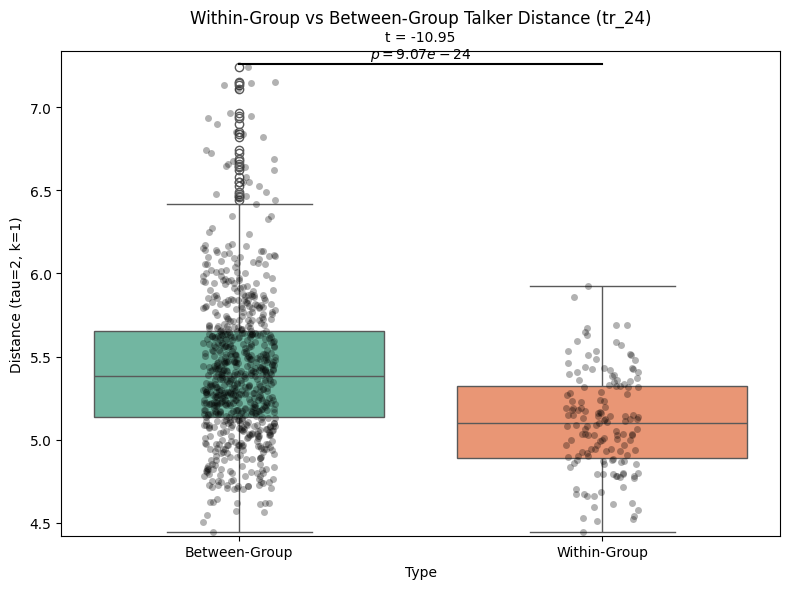

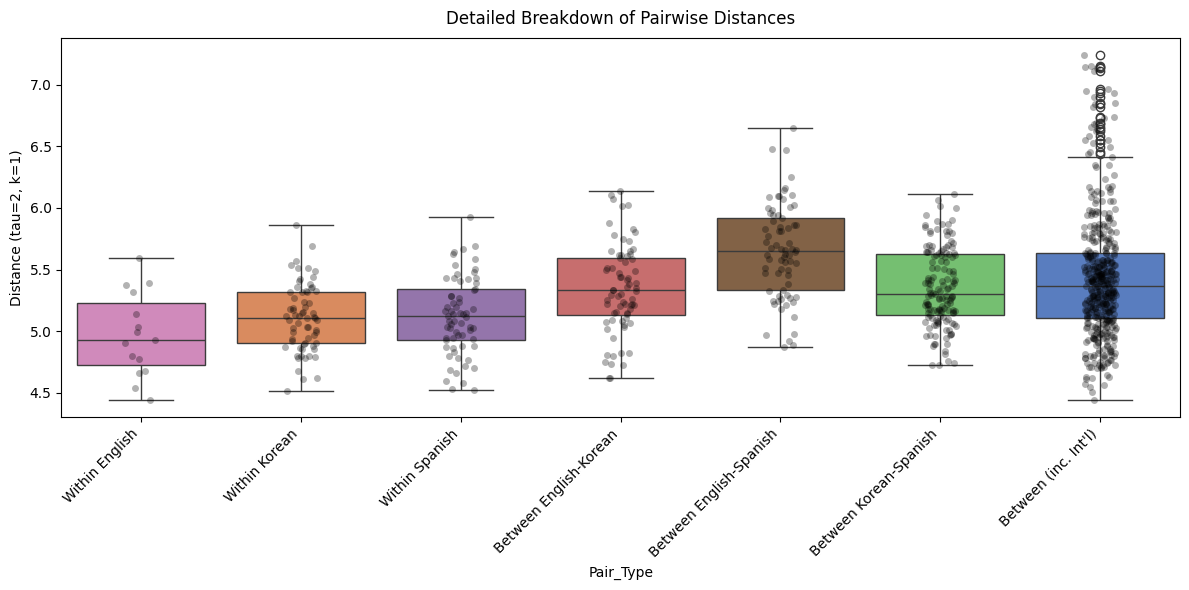

In [19]:
# 3. Visualization of Within-Group vs Between-Group Distance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for visualization
dist_data = []
for i in range(len(valid_talkers)):
    for j in range(i+1, len(valid_talkers)):
        t1, t2 = valid_talkers[i], valid_talkers[j]
        g1, g2 = get_talker_group(t1), get_talker_group(t2)
        dist = pairwise_dists.get((t1, t2), np.nan)
        
        if not np.isnan(dist):
            is_within = (g1 == g2)
            # Only include groups that have more than 1 talker for 'Within'
            if is_within and g1 not in ['English', 'Korean', 'Spanish']:
                continue
                
            dist_data.append({
                'Talker1': t1,
                'Talker2': t2,
                'Group1': g1,
                'Group2': g2,
                'Distance': dist,
                'Type': 'Within-Group' if is_within else 'Between-Group'
            })

df_dist = pd.DataFrame(dist_data)

plt.figure(figsize=(8, 6))
sns.boxplot(x='Type', y='Distance', data=df_dist, hue='Type', palette='Set2', legend=False)
sns.stripplot(x='Type', y='Distance', data=df_dist, color='black', alpha=0.3, jitter=True)

# Add statistical annotation
y_max = df_dist['Distance'].max()
plt.plot([0, 1], [y_max + 0.02, y_max + 0.02], lw=1.5, c='k')
plt.text(0.5, y_max + 0.025, f"t = {t_stat:.2f}\n$p = {p_val:.2e}$", ha='center', va='bottom', color='k')

plt.title("Within-Group vs Between-Group Talker Distance (tr_24)", pad=20)
plt.ylabel("Distance (tau=2, k=1)")
plt.ylim(df_dist['Distance'].min() - 0.02, y_max + 0.1)
plt.tight_layout()
plt.show()

# Further breakdown by specific L1 pairs
def get_pair_type(row):
    g1, g2 = sorted([row['Group1'], row['Group2']])
    if row['Type'] == 'Within-Group':
        return f"Within {g1}"
    elif g1 in ['English', 'Korean', 'Spanish'] and g2 in ['English', 'Korean', 'Spanish']:
        return f"Between {g1}-{g2}"
    else:
        return "Between (inc. Int'l)"

df_dist['Pair_Type'] = df_dist.apply(get_pair_type, axis=1)

# Sort order for plotting
order = ['Within English', 'Within Korean', 'Within Spanish', 
         'Between English-Korean', 'Between English-Spanish', 'Between Korean-Spanish', 
         "Between (inc. Int'l)"]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Pair_Type', y='Distance', data=df_dist, order=order, hue='Pair_Type', palette='muted', legend=False)
sns.stripplot(x='Pair_Type', y='Distance', data=df_dist, order=order, color='black', alpha=0.3, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.title("Detailed Breakdown of Pairwise Distances", pad=10)
plt.ylabel("Distance (tau=2, k=1)")
plt.tight_layout()
plt.show()


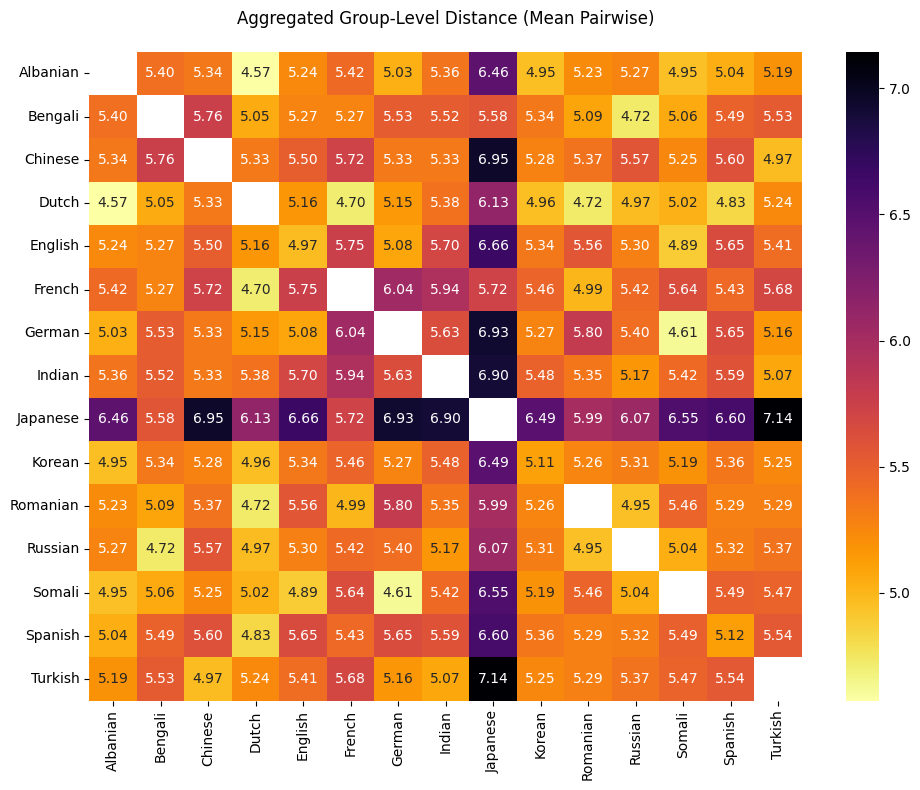

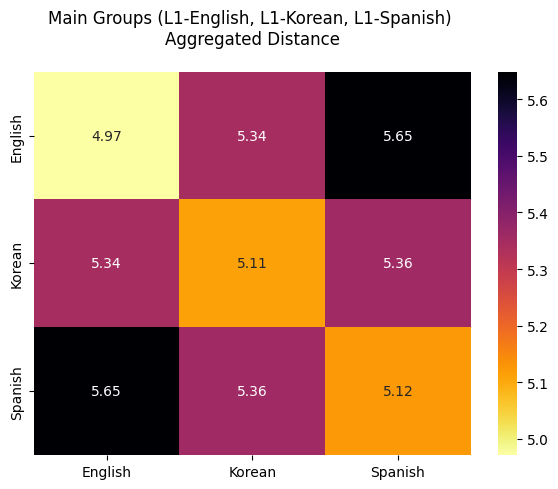

In [20]:
# 4. Aggregated Group-Level Distance Heatmap
# Here we calculate the mean distance between each pair of groups and plot it as a heatmap.

# Get all unique groups
all_groups = sorted(list(set([get_talker_group(t) for t in valid_talkers])))

# Initialize the aggregated matrix
agg_dist_matrix = np.zeros((len(all_groups), len(all_groups)))

for i, g1 in enumerate(all_groups):
    for j, g2 in enumerate(all_groups):
        dists = []
        # Find all pairs of talkers between g1 and g2
        talkers1 = [t for t in valid_talkers if get_talker_group(t) == g1]
        talkers2 = [t for t in valid_talkers if get_talker_group(t) == g2]
        
        for t1 in talkers1:
            for t2 in talkers2:
                if t1 != t2: # Exclude self-distance
                    dist = pairwise_dists.get((t1, t2), np.nan)
                    if not np.isnan(dist):
                        dists.append(dist)
                        
        if dists:
            agg_dist_matrix[i, j] = np.mean(dists)
        else:
            agg_dist_matrix[i, j] = np.nan 

plt.figure(figsize=(10, 8))
sns.heatmap(agg_dist_matrix, fmt='.2f', xticklabels=all_groups, yticklabels=all_groups, 
            cmap='inferno_r', annot=True)
plt.title("Aggregated Group-Level Distance (Mean Pairwise)", pad=20)
plt.tight_layout()
plt.show()

# If we just want the main 3 groups for a cleaner condition plot:
main_groups = ['English', 'Korean', 'Spanish']
main_agg_dist_matrix = np.zeros((len(main_groups), len(main_groups)))

for i, g1 in enumerate(main_groups):
    for j, g2 in enumerate(main_groups):
        dists = []
        talkers1 = [t for t in valid_talkers if get_talker_group(t) == g1]
        talkers2 = [t for t in valid_talkers if get_talker_group(t) == g2]
        for t1 in talkers1:
            for t2 in talkers2:
                if t1 != t2:
                    dist = pairwise_dists.get((t1, t2), np.nan)
                    if not np.isnan(dist):
                        dists.append(dist)
        if dists:
            main_agg_dist_matrix[i, j] = np.mean(dists)

plt.figure(figsize=(6, 5))
sns.heatmap(main_agg_dist_matrix, fmt='.2f', xticklabels=main_groups, yticklabels=main_groups, 
            cmap='inferno_r', annot=True)
plt.title("Main Groups (L1-English, L1-Korean, L1-Spanish) \nAggregated Distance", pad=20)
plt.tight_layout()
plt.show()


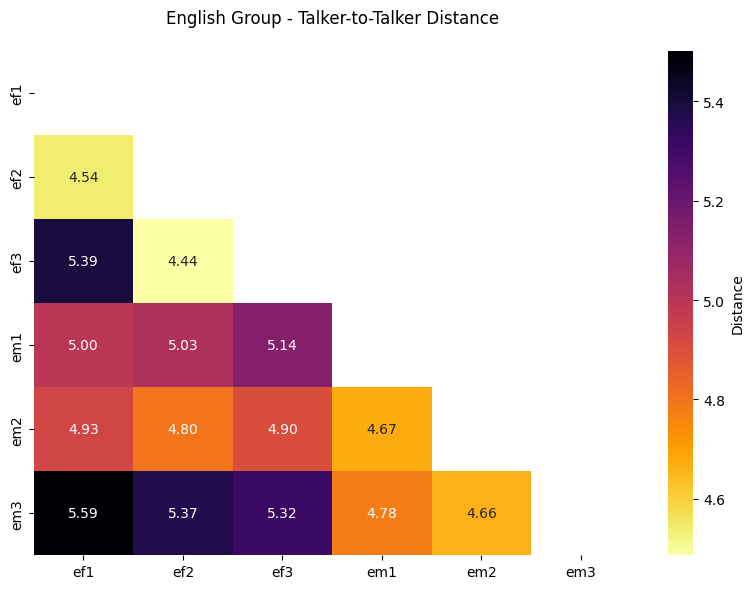

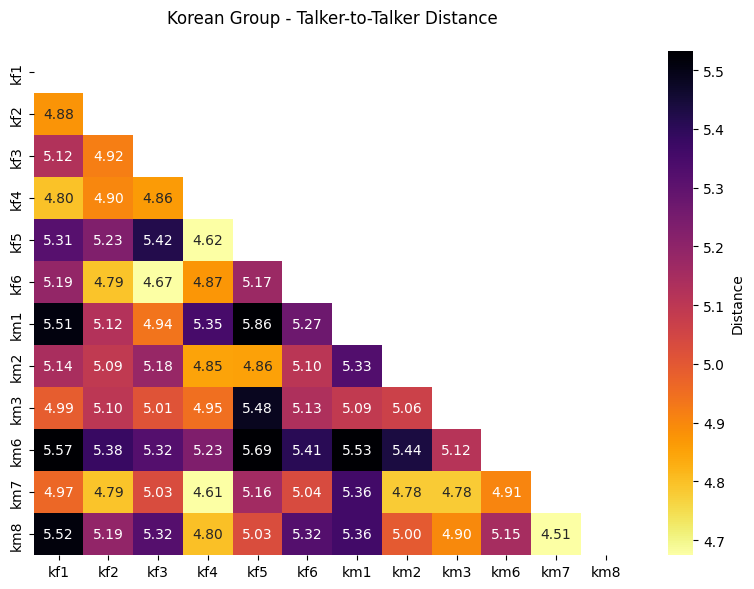

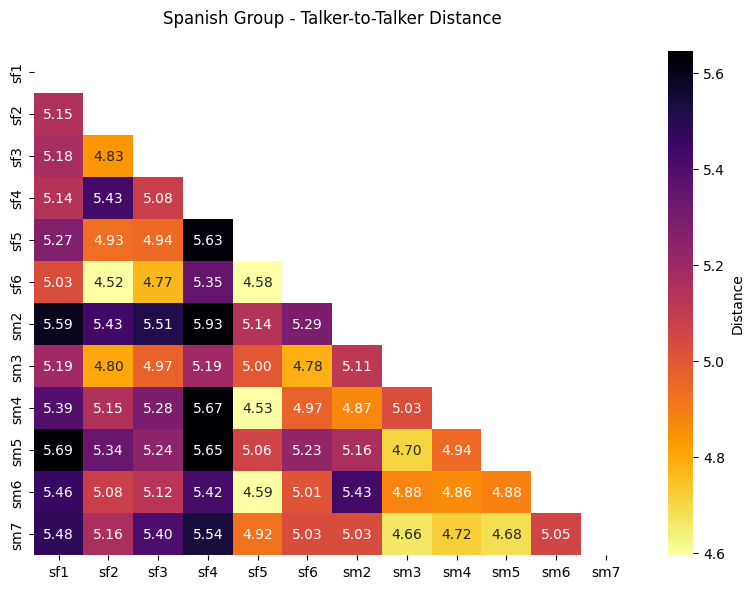

In [21]:
# 5. Separate Talker-to-Talker Heatmaps for English, Korean, and Spanish
groups_to_plot = ['English', 'Korean', 'Spanish']

for g in groups_to_plot:
    # Filter talkers for this group, sorted
    g_talkers = sorted([t for t in valid_talkers if get_talker_group(t) == g])
    
    # Initialize distance matrix
    n = len(g_talkers)
    g_dist_matrix = np.zeros((n, n))
    
    for i, t1 in enumerate(g_talkers):
        for j, t2 in enumerate(g_talkers):
            if i == j:
                g_dist_matrix[i, j] = np.nan
            else:
                g_dist_matrix[i, j] = pairwise_dists.get((t1, t2), 0.0)
                
    mask = np.triu(np.ones_like(g_dist_matrix, dtype=bool))
    
    labels = [get_talker_label(t).replace(f'{g}_', '') for t in g_talkers] 
    
    plt.figure(figsize=(8, 6))
    
    # Use percentiles to clamp colormap for better contrast
    vmin = np.nanpercentile(g_dist_matrix, 5)
    vmax = np.nanpercentile(g_dist_matrix, 95)
    
    sns.heatmap(g_dist_matrix, mask=mask, xticklabels=labels, yticklabels=labels, 
                cmap='inferno_r', annot=True, fmt='.2f', vmin=vmin, vmax=vmax,
                cbar_kws={'label': 'Distance'})
    plt.title(f"{g} Group - Talker-to-Talker Distance", pad=20)
    plt.tight_layout()
    plt.show()
